In [23]:
import pandas as pd
import altair as alt
import numpy as np
import os
import kagglehub
import unicodedata
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

# Enable VegaFusion for large datasets
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [24]:
# Create a function to normalize Artist Names that have special characters to their closes ASCII equivalents
# Function created with assistance by Claude AI
def normalize_text(text):
    if isinstance(text, str):
        # Decompose special characters, the encode to ASCII 
        return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')

# Use KaggleDatasetAdapter to download the dataset programatically
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sanjanchaudhari/spotify-dataset/versions/1",
    "cleaned_dataset.csv",
)

# Save the raw file in a csv in the directory
df.to_csv("../data/raw/spotify_raw.csv")

# Apply normalization of characters to Artist, Song and Album Names
df['Artist'] = df['Artist'].apply(normalize_text)
df['Album'] = df['Album'].apply(normalize_text)
df['Track'] = df['Track'].apply(normalize_text)
df['Title'] = df['Title'].apply(normalize_text)

# Drop Columns That Will Not Be Used For Space Saving
#df = df.drop(columns=['Title', 'Album_type', 'official_video', 'Channel'])

# Save the clean file in a csv in the directory
df.to_csv("../data/clean/spotify_clean.csv")

In [25]:
# Preview first 5 rows
df.head()

,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,True,True,1.040235e+09,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,True,True,3.100837e+08,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,True,True,6.306347e+07,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,True,True,4.346636e+08,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,True,True,6.172597e+08,9.942693,Youtube


In [26]:
# Check data types and nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20594 entries, 0 to 20593
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20594 non-null  str    
 1   Track             20594 non-null  str    
 2   Album             20594 non-null  str    
 3   Album_type        20594 non-null  str    
 4   Danceability      20594 non-null  float64
 5   Energy            20594 non-null  float64
 6   Loudness          20594 non-null  float64
 7   Speechiness       20594 non-null  float64
 8   Acousticness      20594 non-null  float64
 9   Instrumentalness  20594 non-null  float64
 10  Liveness          20594 non-null  float64
 11  Valence           20594 non-null  float64
 12  Tempo             20594 non-null  float64
 13  Duration_min      20594 non-null  float64
 14  Title             20594 non-null  str    
 15  Channel           20594 non-null  str    
 16  Views             20594 non-null  float64
 17  Like

In [27]:
# Confirm The Scale of the original dataframe musical features. 
df.describe()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min,Views,Likes,Comments,Stream,EnergyLiveness
count,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,2.059400e+04,2.059400e+04,2.059400e+04,2.059400e+04,20592.000000
mean,0.620102,0.635176,-7.678254,0.096733,0.291391,0.056162,0.193653,0.530077,120.562616,3.742439,9.203740e+07,6.479902e+05,2.684679e+04,1.326446e+08,5.167227
std,0.165504,0.214274,4.639481,0.112182,0.286117,0.193622,0.168832,0.245542,29.588093,2.085211,2.726026e+08,1.773648e+06,1.911751e+05,2.423582e+08,4.117431
min,0.000000,0.000000,-46.251000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000049
25%,0.519000,0.507000,-8.868000,0.035700,0.045200,0.000000,0.094100,0.340000,96.994000,2.996746,1.478284e+06,1.754200e+04,4.060000e+02,1.559098e+07,2.386190
50%,0.638000,0.666000,-6.540500,0.050650,0.193000,0.000002,0.125000,0.538000,119.959000,3.551267,1.331348e+07,1.153155e+05,3.006000e+03,4.730525e+07,4.256881
75%,0.741000,0.798000,-4.935000,0.104000,0.476750,0.000474,0.237000,0.727000,139.923500,4.202163,6.739682e+07,5.000198e+05,1.373675e+04,1.343453e+08,6.822034
max,0.975000,1.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,77.934300,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09,59.113924


In [28]:
# List all Musical Features
musical_features = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'EnergyLiveness',
                    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo']

# Create MinMax Scaler for All Song Attributes To Place Them On A Uniform Scale
scaler = MinMaxScaler(feature_range=(0, 10))

# Apply scaling to all song feature columns
for feature in musical_features:
    df[feature] = scaler.fit_transform(df[[feature]])
    
#confirm the scale of the musical features has now been adjusted to Range(0, 10)
df.describe()



,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min,Views,Likes,Comments,Stream,EnergyLiveness
count,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,2.059400e+04,2.059400e+04,2.059400e+04,2.059400e+04,20592.000000
mean,6.360019,6.351761,8.177216,1.003455,2.925612,0.561619,1.936533,5.338136,4.953841,3.742439,9.203740e+07,6.479902e+05,2.684679e+04,1.326446e+08,0.874106
std,1.697479,2.142742,0.983545,1.163714,2.872661,1.936215,1.688321,2.472733,1.215756,2.085211,2.726026e+08,1.773648e+06,1.911751e+05,2.423582e+08,0.696525
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,5.323077,5.070000,7.924996,0.370332,0.453815,0.000000,0.941000,3.423968,3.985421,2.996746,1.478284e+06,1.754200e+04,4.060000e+02,1.559098e+07,0.403652
50%,6.543590,6.660000,8.418414,0.525415,1.937751,0.000024,1.250000,5.417925,4.929039,3.551267,1.331348e+07,1.153155e+05,3.006000e+03,4.730525e+07,0.720107
75%,7.600000,7.980000,8.758771,1.078838,4.786647,0.004737,2.370000,7.321249,5.749367,4.202163,6.739682e+07,5.000198e+05,1.373675e+04,1.343453e+08,1.154041
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,77.934300,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09,10.000000


In [29]:
# Create a box plot of the musical features
artist = 'Beyonce'

# Filter the df by the selected artist
filtered_df = df[df['Artist'] == artist]

# Keep only the musical features in the filtered df
filtered_df = filtered_df[musical_features]

# Create a Box Plot of the artist's musical features
fig = px.box(filtered_df)
fig.update_layout(showlegend=False, yaxis_title=None, xaxis_title=None)


fig.show()


In [30]:
filtered_df

,Danceability,Energy,Loudness,Speechiness,EnergyLiveness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
350,8.000000,6.89,8.603379,1.462656,1.669830,0.369478,0.000097,0.698,6.465257,4.727002
351,6.625641,7.70,8.406648,2.344398,1.821769,0.025000,0.000000,0.715,6.858006,4.074626
352,5.589744,6.41,8.448623,1.035270,0.634113,0.045482,0.000659,1.710,4.672709,5.008464
353,7.107692,8.87,8.736724,0.824689,0.555730,0.583333,0.000027,2.700,8.700906,4.722893
354,5.210256,7.20,8.552500,0.651452,2.163381,2.730924,0.000000,0.563,4.753273,3.286450
355,6.687179,7.49,8.692417,0.919087,0.209768,0.851406,0.000000,6.040,6.555891,3.866632
356,9.261538,5.19,7.865002,2.697095,0.566422,2.821285,0.001060,1.550,5.911380,4.724907
357,6.020513,2.99,8.243624,0.272822,0.411214,7.821285,0.000000,1.230,3.585096,3.903161
358,5.979487,6.21,8.341778,0.496888,0.580387,0.097590,0.010600,1.810,4.018127,5.753990
359,7.507692,8.99,8.906744,1.483402,0.408807,0.049799,0.000464,3.720,7.643505,5.222088


In [31]:
filtered_df[sorted(filtered_df)]

,Acousticness,Danceability,Energy,EnergyLiveness,Instrumentalness,Liveness,Loudness,Speechiness,Tempo,Valence
350,0.369478,8.000000,6.89,1.669830,0.000097,0.698,8.603379,1.462656,4.727002,6.465257
351,0.025000,6.625641,7.70,1.821769,0.000000,0.715,8.406648,2.344398,4.074626,6.858006
352,0.045482,5.589744,6.41,0.634113,0.000659,1.710,8.448623,1.035270,5.008464,4.672709
353,0.583333,7.107692,8.87,0.555730,0.000027,2.700,8.736724,0.824689,4.722893,8.700906
354,2.730924,5.210256,7.20,2.163381,0.000000,0.563,8.552500,0.651452,3.286450,4.753273
355,0.851406,6.687179,7.49,0.209768,0.000000,6.040,8.692417,0.919087,3.866632,6.555891
356,2.821285,9.261538,5.19,0.566422,0.001060,1.550,7.865002,2.697095,4.724907,5.911380
357,7.821285,6.020513,2.99,0.411214,0.000000,1.230,8.243624,0.272822,3.903161,3.585096
358,0.097590,5.979487,6.21,0.580387,0.010600,1.810,8.341778,0.496888,5.753990,4.018127
359,0.049799,7.507692,8.99,0.408807,0.000464,3.720,8.906744,1.483402,5.222088,7.643505


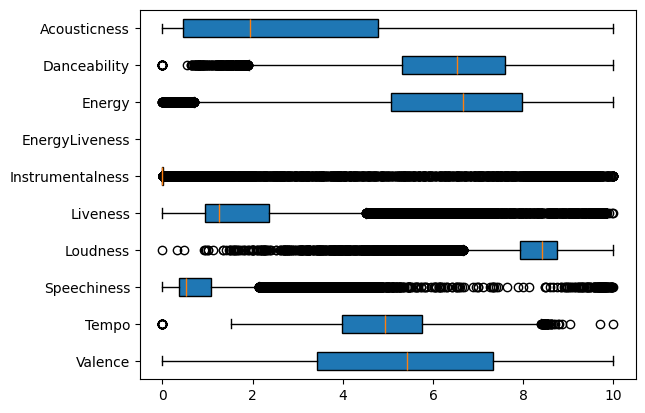

In [32]:
labels = sorted(filtered_df)
df_sorted = df[labels]

fig_box, ax_box = plt.subplots()

bplot = ax_box.boxplot(
    df_sorted, 
    patch_artist=True,
    tick_labels=labels,
    orientation='horizontal'
)
plt.gca().invert_yaxis()
plt.show()

In [33]:
filtered_df_melt = pd.melt(df[musical_features], var_name='Feature', value_name='Value')

alt.Chart(filtered_df_melt).mark_boxplot().encode(
    alt.X("Value:Q"), 
    alt.Y("Feature:N").title(None), 
    alt.Color("Feature:N").legend(None)
)

alt.Chart(...)

In [34]:
# Create a summary of the musical features for the bar plot
summary_df = pd.DataFrame(filtered_df.apply(np.mean, axis=0))


# Create a Bar Plot of the summarized features
fig = px.bar(summary_df, color=summary_df.index)
fig.update_layout(showlegend=False, yaxis_title=None, xaxis_title=None)
fig.show()


In [35]:
# Show only columns with nulls
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

EnergyLiveness    2
dtype: int64

In [36]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [37]:
# Distribution of numerical features
df.describe()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min,Views,Likes,Comments,Stream,EnergyLiveness
count,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,2.059400e+04,2.059400e+04,2.059400e+04,2.059400e+04,20592.000000
mean,6.360019,6.351761,8.177216,1.003455,2.925612,0.561619,1.936533,5.338136,4.953841,3.742439,9.203740e+07,6.479902e+05,2.684679e+04,1.326446e+08,0.874106
std,1.697479,2.142742,0.983545,1.163714,2.872661,1.936215,1.688321,2.472733,1.215756,2.085211,2.726026e+08,1.773648e+06,1.911751e+05,2.423582e+08,0.696525
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,5.323077,5.070000,7.924996,0.370332,0.453815,0.000000,0.941000,3.423968,3.985421,2.996746,1.478284e+06,1.754200e+04,4.060000e+02,1.559098e+07,0.403652
50%,6.543590,6.660000,8.418414,0.525415,1.937751,0.000024,1.250000,5.417925,4.929039,3.551267,1.331348e+07,1.153155e+05,3.006000e+03,4.730525e+07,0.720107
75%,7.600000,7.980000,8.758771,1.078838,4.786647,0.004737,2.370000,7.321249,5.749367,4.202163,6.739682e+07,5.000198e+05,1.373675e+04,1.343453e+08,1.154041
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,77.934300,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09,10.000000


In [38]:
# Create summary table grouped by Danceability

# Initialize column with default value and update depending on condition
df["dance_bin"] = "Mid" 
df.loc[df["Danceability"] < 0.4, "dance_bin"] = "Low"
df.loc[df["Danceability"] >= 0.7, "dance_bin"] = "High"

df["dance_bin"] = df["dance_bin"].astype(str)

summary = df.groupby("dance_bin")[["Likes", "Views"]].mean()
summary = summary.round(0).astype(int).reset_index()

# Set order for category in summary table
bin_order = ["Low", "Mid", "High"]
summary["dance_bin"] = pd.Categorical(summary["dance_bin"], 
                                      categories=bin_order, ordered=True)
summary = summary.sort_values("dance_bin").reset_index(drop=True)

summary

,dance_bin,Likes,Views
0,Low,50932,11926753
1,Mid,13643,655243
2,High,648758,92142508


In [39]:
# Create base bar chart
chart = alt.Chart(df).mark_bar().encode(
    alt.X("dance_bin:N", 
          title="Danceability Level",
         sort=["Low", "Mid", "High"]),
    alt.Y("mean(Likes):Q", 
          title="Average Likes", 
          axis=alt.Axis(format="~s")),
    color=alt.Color("dance_bin:N", 
                    legend=None,
                    scale=alt.Scale(scheme="set2", domain=["Low", "Mid", "High"]))
)

# Create error bars
error_bars = alt.Chart(df).mark_errorbar(
    extent='ci', 
    ticks={"thickness":3, "size": 16},
    color="black"
).encode(
    alt.X("dance_bin:N", sort=["Low", "Mid", "High"]),
    alt.Y("Likes:Q")
)
    
final_chart = (chart + error_bars).properties(
    title=alt.TitleParams(
        text="Average Song Likes by Danceability Level",
        subtitle="Error bars represent 95% Confidence Intervals (CI)"),
    width=300,
    height=300
).configure_axis(
    labelFontSize=12,
    titleFontSize=16,
    labelAngle=0
).configure_title(
    fontSize=20
)

final_chart

alt.LayerChart(...)

In [40]:
# Save chart to img folder
output_path = "../img/danceability_eda.png"

final_chart.save(output_path, ppi=300)